In [1]:
import pandas as pd
df = pd.read_csv("IBM_HR_Attrition_Enhanced.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,TenureGroup,MonthlyIncomeBracket,OverallSatisfactionIndex
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,1,6,4,0,5,35-44,Established (6-10 yrs),High,2.00
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,3,10,7,1,7,45-54,Established (6-10 yrs),High,3.00
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,3,0,0,0,0,35-44,New (0-2 yrs),Low,3.00
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,8,7,3,0,25-34,Established (6-10 yrs),Low,3.25
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,3,2,2,2,2,25-34,New (0-2 yrs),Medium,2.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,3,5,2,0,3,35-44,Early (3-5 yrs),Low,3.25
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,5,3,7,7,1,7,35-44,Established (6-10 yrs),Very High,2.25
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,0,3,6,2,0,3,25-34,Established (6-10 yrs),High,2.25
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,3,2,9,6,0,8,45-54,Established (6-10 yrs),High,3.00


In [2]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,TenureGroup,MonthlyIncomeBracket,OverallSatisfactionIndex
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,1,6,4,0,5,35-44,Established (6-10 yrs),High,2.00
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,3,10,7,1,7,45-54,Established (6-10 yrs),High,3.00
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,3,0,0,0,0,35-44,New (0-2 yrs),Low,3.00
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,8,7,3,0,25-34,Established (6-10 yrs),Low,3.25
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,3,2,2,2,2,25-34,New (0-2 yrs),Medium,2.50


In [3]:
print(df.shape)
print(df.isnull().sum())

(1470, 39)
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0

## Exploratory Data Analysis (EDA)
## Attrition by Department

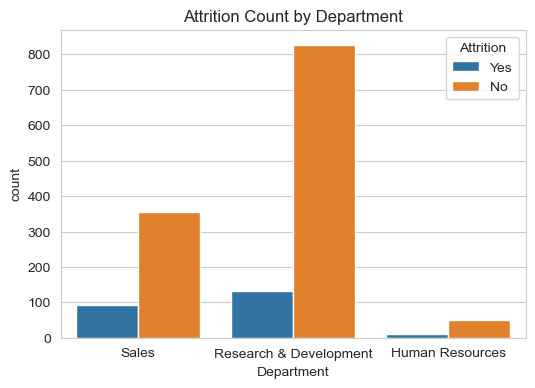

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Department", hue="Attrition")
plt.title("Attrition Count by Department")
plt.show()

## Attrition by OverTime


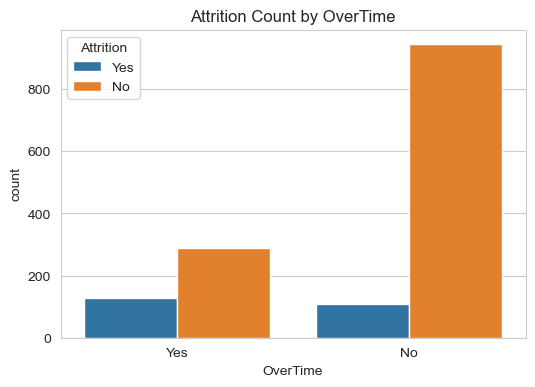

In [6]:
plt.figure(figsize=(6,4))                                   # creates a blank canvas
sns.countplot(data=df, x="OverTime", hue="Attrition")        
plt.title("Attrition Count by OverTime")                     
plt.show()                                                   


## Monthly Income vs Attrition
## Do lower-income employees leave more often?

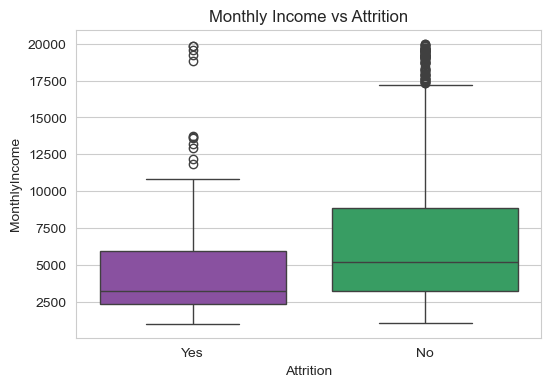

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome",hue = "Attrition", palette=["#8E44AD", "#27AE60"])
plt.title("Monthly Income vs Attrition")
plt.show()

## Age vs Attrition

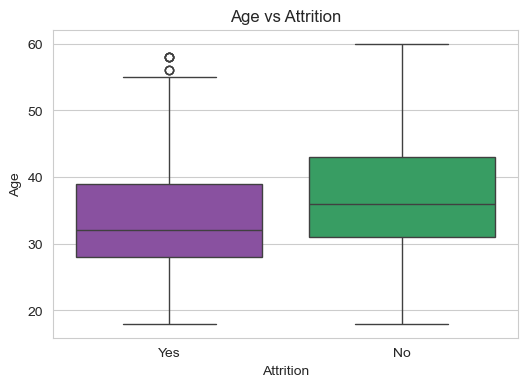

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Attrition", y="Age", hue="Attrition", palette=["#8E44AD", "#27AE60"], legend=False)
plt.title("Age vs Attrition")
plt.show()   

## Correlation Heatmap

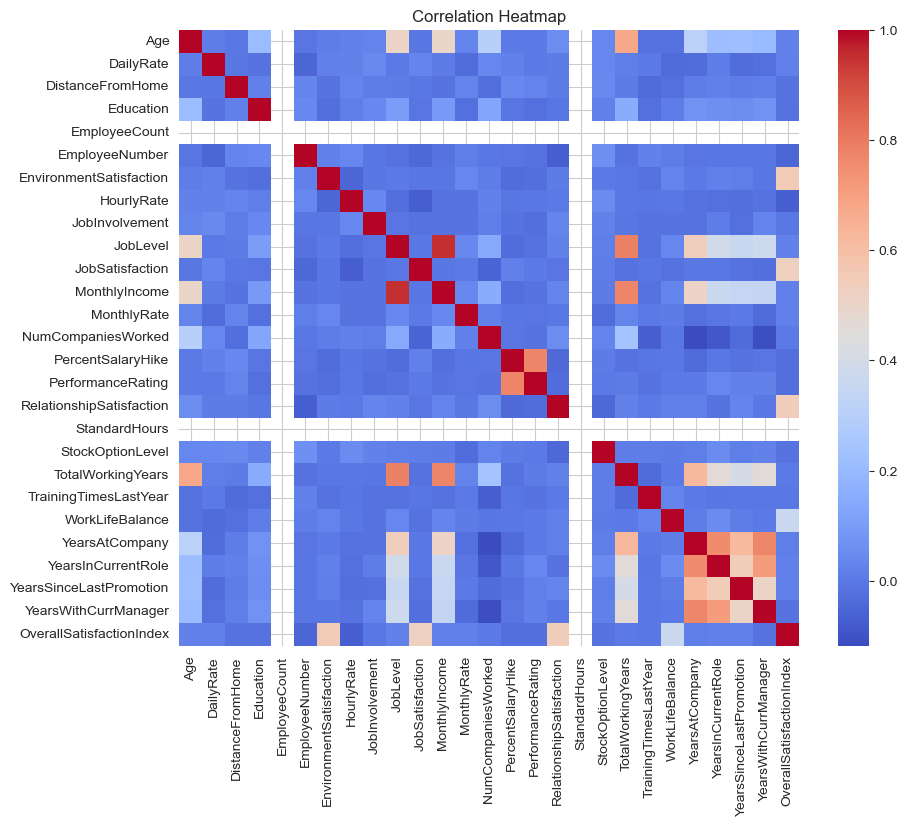

In [9]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Encode Categorical Columns

In [10]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])
df_encoded.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeGroup,TenureGroup,MonthlyIncomeBracket,OverallSatisfactionIndex
0,41,1,2,1102,2,1,2,1,1,1,...,0,1,6,4,0,5,1,1,0,2.00
1,49,0,1,279,1,8,1,1,1,2,...,3,3,10,7,1,7,2,1,0,3.00
2,37,1,2,1373,1,2,2,4,1,4,...,3,3,0,0,0,0,1,2,1,3.00
3,33,0,1,1392,1,3,4,1,1,5,...,3,3,8,7,3,0,0,1,1,3.25
4,27,0,2,591,1,2,1,3,1,7,...,3,3,2,2,2,2,0,2,2,2.50


## Split Data into Train and Test

In [11]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1176, 38) (294, 38) (1176,) (294,)


## Train the Model

In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluate the Model

Accuracy: 0.8673469387755102
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       255
           1       0.50      0.05      0.09        39

    accuracy                           0.87       294
   macro avg       0.69      0.52      0.51       294
weighted avg       0.82      0.87      0.82       294



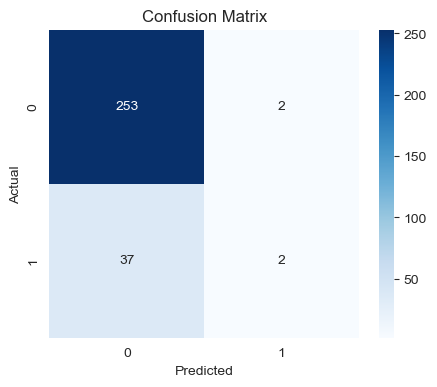

In [15]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Handle Class Imbalance

In [23]:
model_balanced = RandomForestClassifier(random_state=42, class_weight="balanced")
model_balanced.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluate Balanced Model

Accuracy (Balanced): 0.8741496598639455
              precision    recall  f1-score   support

           0       0.88      0.99      0.93       255
           1       0.67      0.10      0.18        39

    accuracy                           0.87       294
   macro avg       0.77      0.55      0.55       294
weighted avg       0.85      0.87      0.83       294



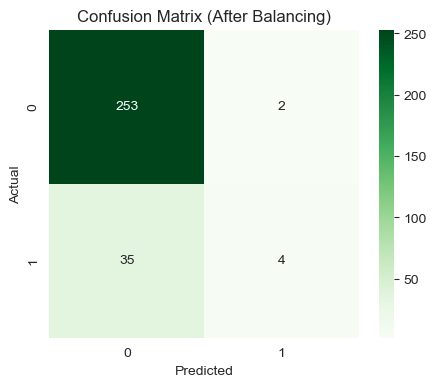

In [24]:
y_pred_balanced = model_balanced.predict(X_test)

print("Accuracy (Balanced):", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

cm_balanced = confusion_matrix(y_test, y_pred_balanced)
plt.figure(figsize=(5,4))
sns.heatmap(cm_balanced, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (After Balancing)")
plt.show()

## Try Lower Threshold

In [25]:
y_prob_balanced = model_balanced.predict_proba(X_test)[:, 1]
y_pred_threshold = (y_prob_balanced > 0.3).astype(int)

print("Recall with lower threshold:", recall_score(y_test, y_pred_threshold))
print(classification_report(y_test, y_pred_threshold))

Recall with lower threshold: 0.28205128205128205
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       255
           1       0.42      0.28      0.34        39

    accuracy                           0.85       294
   macro avg       0.66      0.61      0.63       294
weighted avg       0.83      0.85      0.84       294



## Before vs After Comparison

In [27]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Recall (Attrition=Yes)"],
    "Before Balancing": [accuracy_score(y_test, y_pred), recall_score(y_test, y_pred)],
    "After Balancing": [accuracy_score(y_test, y_pred_balanced), recall_score(y_test, y_pred_balanced)],
    "After Balancing + Lower Threshold": [accuracy_score(y_test, y_pred_threshold), recall_score(y_test, y_pred_threshold)]
})
print(comparison)

                   Metric  Before Balancing  After Balancing  \
0                Accuracy          0.867347         0.874150   
1  Recall (Attrition=Yes)          0.051282         0.102564   

   After Balancing + Lower Threshold  
0                           0.853741  
1                           0.282051  


## Feature Importance

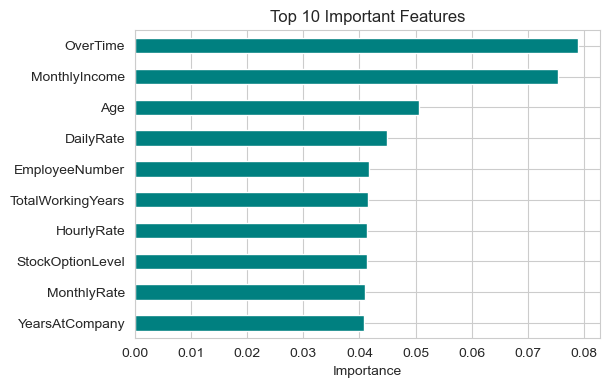

OverTime             0.078915
MonthlyIncome        0.075296
Age                  0.050531
DailyRate            0.044838
EmployeeNumber       0.041757
TotalWorkingYears    0.041582
HourlyRate           0.041341
StockOptionLevel     0.041312
MonthlyRate          0.040903
YearsAtCompany       0.040823
dtype: float64


In [19]:
importances = pd.Series(model_balanced.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(6,4))
importances.sort_values().plot(kind="barh", color="teal")
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.show()

print(importances)